# 🧬 DNA Sequence Classification using Machine Learning

## 📌 Overview
This project focuses on the classification of DNA sequences into **promoter** and **non-promoter** regions using machine learning techniques.

## Biological Background
A **promoter** is a regulatory region of DNA located upstream of a gene. It plays a key role in gene expression by serving as the binding site for RNA polymerase and transcription factors, initiating gene transcription. Identifying promoter regions is important because it helps understand how genes are activated and regulated.

## Why this task matters
Promoter classification is a relevant problem in bioinformatics because it helps distinguish regulatory DNA regions involved in gene regulation from non-functional background sequences. This makes promoter prediction useful for understanding gene expression and, more broadly, for applications in genomics and biomedical research.

## Project Objective
The aim of this project is to transform DNA sequences into numerical representations, compare multiple machine learning models for binary classification, and evaluate their performance on a held-out test set.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

from sklearn import model_selection
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, classification_report, 
                            confusion_matrix, ConfusionMatrixDisplay,
                            roc_curve, roc_auc_score)

## 2. Load the dataset
The dataset contains labeled DNA sequences. Each sequence is associated with a promoter (+) or non-promoter (-) class.

In [2]:
names = ['Class','id','Sequence']
data = pd.read_csv("../data/raw/promoters.data.txt", names=names)

print("Dataset shape: ", data.shape)
data.head()

Dataset shape:  (106, 3)


,Class,id,Sequence
0,+,S10,\t\ttactagcaatacgcttgcgttcggtggttaagtatgtataat...
1,+,AMPC,\t\ttgctatcctgacagttgtcacgctgattggtgtcgttacaat...
2,+,AROH,\t\tgtactagagaactagtgcattagcttatttttttgttatcat...
3,+,DEOP2,\taattgtgatgtgtatcgaagtgtgttgcggagtagatgttagaa...
4,+,LEU1_TRNA,\ttcgataattaactattgacgaaaagctgaaaaccactagaatgc...


## 3. Preprocess DNA sequences
Each DNA sequence is split into individual nucleotides. Tab characters are removed, and the corresponding class label is appended so that each sequence can later be converted into a structured tabular format.

In [3]:
classes = data.loc[:, 'Class']
sequences = list(data.loc[:, 'Sequence'])

print("Number of sequences:", len(sequences))
print("First class labels:")
print(classes[:5])

Number of sequences: 106
First class labels:
0    +
1    +
2    +
3    +
4    +
Name: Class, dtype: object


In [4]:
dataset = {}

# loop through sequences and split into individual nucleotides
for i, seq in enumerate(sequences):

    # split into nucleotides, remove tab characters
    nucleotides = list(seq)
    nucleotides = [x for x in nucleotides if x != '\t']

    # append class assignment
    nucleotides.append(classes[i])

    # add to dataset
    dataset[i] = nucleotides

print("Example processed sequence:")
print(dataset[0])

Example processed sequence:
['t', 'a', 'c', 't', 'a', 'g', 'c', 'a', 'a', 't', 'a', 'c', 'g', 'c', 't', 't', 'g', 'c', 'g', 't', 't', 'c', 'g', 'g', 't', 'g', 'g', 't', 't', 'a', 'a', 'g', 't', 'a', 't', 'g', 't', 'a', 't', 'a', 'a', 't', 'g', 'c', 'g', 'c', 'g', 'g', 'g', 'c', 't', 't', 'g', 't', 'c', 'g', 't', '+']


## 4. Create a structured DataFrame
Each nucleotide position is represented as a separate feature column, while the final column contains the target class.

In [5]:
dframe = pd.DataFrame(dataset)
df = dframe.transpose()
df.rename(columns = {57: 'Class'}, inplace = True)

print("Structured DataFrame shape:", df.shape)
df.head()

Structured DataFrame shape: (106, 58)


,0,1,2,3,4,5,6,7,8,9,...,48,49,50,51,52,53,54,55,56,Class
0,t,a,c,t,a,g,c,a,a,t,...,g,c,t,t,g,t,c,g,t,+
1,t,g,c,t,a,t,c,c,t,g,...,c,a,t,c,g,c,c,a,a,+
2,g,t,a,c,t,a,g,a,g,a,...,c,a,c,c,c,g,g,c,g,+
3,a,a,t,t,g,t,g,a,t,g,...,a,a,c,a,a,a,c,t,c,+
4,t,c,g,a,t,a,a,t,t,a,...,c,c,g,t,g,g,t,a,g,+


## 5. Explore the data
This section inspects the class balance and the categorical structure of the sequence positions.

In [6]:
#General overview of categorical sequence data
df.describe(include='all')

,0,1,2,3,4,5,6,7,8,9,...,48,49,50,51,52,53,54,55,56,Class
count,106,106,106,106,106,106,106,106,106,106,...,106,106,106,106,106,106,106,106,106,106
unique,4,4,4,4,4,4,4,4,4,4,...,4,4,4,4,4,4,4,4,4,2
top,t,a,a,c,a,a,a,a,a,a,...,c,c,c,t,t,c,c,t,t,+
freq,38,34,30,30,36,42,38,34,33,36,...,36,42,31,33,35,32,29,29,34,53


In [7]:
print("Class distribution:")
df['Class'].value_counts()

Class distribution:


Class
+    53
-    53
Name: count, dtype: int64

In [8]:
#Exploring dataset
series = []
for name in df.columns:
    series.append(df[name].value_counts())

info = pd.DataFrame(series)
details = info.transpose()
print(details)

   count  count  count  count  count  count  count  count  count  count  ...  \
t   38.0   26.0   27.0   26.0   22.0   24.0   30.0   32.0   32.0   28.0  ...   
c   27.0   22.0   21.0   30.0   19.0   18.0   21.0   20.0   22.0   22.0  ...   
a   26.0   34.0   30.0   22.0   36.0   42.0   38.0   34.0   33.0   36.0  ...   
g   15.0   24.0   28.0   28.0   29.0   22.0   17.0   20.0   19.0   20.0  ...   
+    NaN    NaN    NaN    NaN    NaN    NaN    NaN    NaN    NaN    NaN  ...   
-    NaN    NaN    NaN    NaN    NaN    NaN    NaN    NaN    NaN    NaN  ...   

   count  count  count  count  count  count  count  count  count  count  
t   21.0   22.0   23.0   33.0   35.0   30.0   23.0   29.0   34.0    NaN  
c   36.0   42.0   31.0   32.0   21.0   32.0   29.0   29.0   17.0    NaN  
a   23.0   24.0   28.0   27.0   25.0   22.0   26.0   24.0   27.0    NaN  
g   26.0   18.0   24.0   14.0   25.0   22.0   28.0   24.0   28.0    NaN  
+    NaN    NaN    NaN    NaN    NaN    NaN    NaN    NaN    NaN   53

In [9]:
print("Unique values in the first few sequence positions:")
for col in df.columns[:5]:
    print(f"Column {col}: {df[col].unique()}")

Unique values in the first few sequence positions:
Column 0: ['t' 'g' 'a' 'c']
Column 1: ['a' 'g' 't' 'c']
Column 2: ['c' 'a' 't' 'g']
Column 3: ['t' 'c' 'a' 'g']
Column 4: ['a' 't' 'g' 'c']


## 6. Encode categorical features
DNA nucleotides are categorical variables, so one-hot encoding is used to transform them into numerical inputs for machine learning models. This approach preserves nucleotide identity at each sequence position without introducing artificial ordinal relationships. 

NOTE: 
False=0, True=1

In [10]:
numerical_df = pd.get_dummies(df)

# Keeping a single binary target column: promoter (+) = 1, non-promoter (-) = 0
df_encoded = numerical_df.drop(columns=['Class_-']).rename(columns={'Class_+': 'Class'})

print("Encoded DataFrame shape:", df_encoded.shape)
df_encoded.head()

Encoded DataFrame shape: (106, 229)


,0_a,0_c,0_g,0_t,1_a,1_c,1_g,1_t,2_a,2_c,...,54_t,55_a,55_c,55_g,55_t,56_a,56_c,56_g,56_t,Class
0,False,False,False,True,True,False,False,False,False,True,...,False,False,False,True,False,False,False,False,True,True
1,False,False,False,True,False,False,True,False,False,True,...,False,True,False,False,False,True,False,False,False,True
2,False,False,True,False,False,False,False,True,True,False,...,False,False,True,False,False,False,False,True,False,True
3,True,False,False,False,True,False,False,False,False,False,...,False,False,False,False,True,False,True,False,False,True
4,False,False,False,True,False,True,False,False,False,False,...,True,True,False,False,False,False,False,True,False,True


## 7. Prepare training and test sets
The encoded dataset is split into features (X) and labels (y), then divided into training and test subsets using stratified sampling to preserve class balance.

In [11]:
# Create X and Y datasets for training
X = df_encoded.drop('Class', axis=1).values
y = df_encoded['Class'].values

# define seed for reproducibility
seed = 1

# Split data into training and testing datasets while preserving class proportions
X_train, X_test, y_train, y_test = model_selection.train_test_split(
                X, y, test_size=0.25, stratify=y, random_state=seed) 

print("Training set shape: ", X_train.shape)
print("Test set shape: ", X_test.shape)

Training set shape:  (79, 228)
Test set shape:  (27, 228)


### 7. Define machine learning models
Several classification algorithms are compared to evaluate their performance on the DNA sequence classification task.

In [12]:
models = {
    "KNN": KNeighborsClassifier(n_neighbors=3),
    "Gaussian Process": GaussianProcessClassifier(1.0 * RBF(1.0), random_state=seed),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=seed),
    "Random Forest": RandomForestClassifier(max_depth=5, n_estimators=10, max_features=1, random_state=seed),
    "Neural Net": MLPClassifier(alpha=1, max_iter=1000, random_state=seed),
    "AdaBoost": AdaBoostClassifier(random_state=seed),
    "Naive Bayes": GaussianNB(),
    "SVM Linear": SVC(kernel='linear', random_state=seed),
    "SVM RBF": SVC(kernel='rbf', random_state=seed),
    "SVM Sigmoid": SVC(kernel='sigmoid', random_state=seed)
}

## 9. Cross-validation performance
Each model is evaluated using 10-fold cross-validation on the training set.

In [13]:
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

In [14]:
cv_results_summary = []

for name, model in models.items():
    kfold = model_selection.KFold(n_splits=10, random_state=seed, shuffle=True)
    scores = model_selection.cross_val_score(model, X_train, y_train, cv=kfold, scoring='accuracy')
    cv_results_summary.append({
        'Model': name,
        'Mean Accuracy': scores.mean(),
        'Std Accuracy': scores.std()
    })

results_df = pd.DataFrame(cv_results_summary).sort_values(
            by='Mean Accuracy', ascending=False).reset_index(drop=True) #reorder the index in the final table
results_df

,Model,Mean Accuracy,Std Accuracy
0,AdaBoost,0.935714,0.085341
1,SVM Sigmoid,0.912500,0.097628
2,SVM Linear,0.898214,0.094170
3,SVM RBF,0.898214,0.075782
4,Naive Bayes,0.898214,0.146178
5,Neural Net,0.898214,0.094170
6,Gaussian Process,0.885714,0.118235
7,KNN,0.748214,0.094643
8,Decision Tree,0.694643,0.172661
9,Random Forest,0.600000,0.183712


Cross-validation provides a more robust estimate of model performance on the training set and reduces the risk of relying on a single random split.

## 10. Test set evaluation
The best-performing model based on cross-validation is trained on the training set and evaluated on the held-out test set.

In [15]:
best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]

best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

print("Best model:", best_model_name)
print("Test accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Best model: AdaBoost
Test accuracy: 0.9629629629629629

Classification Report:

              precision    recall  f1-score   support

       False       1.00      0.92      0.96        13
        True       0.93      1.00      0.97        14

    accuracy                           0.96        27
   macro avg       0.97      0.96      0.96        27
weighted avg       0.97      0.96      0.96        27



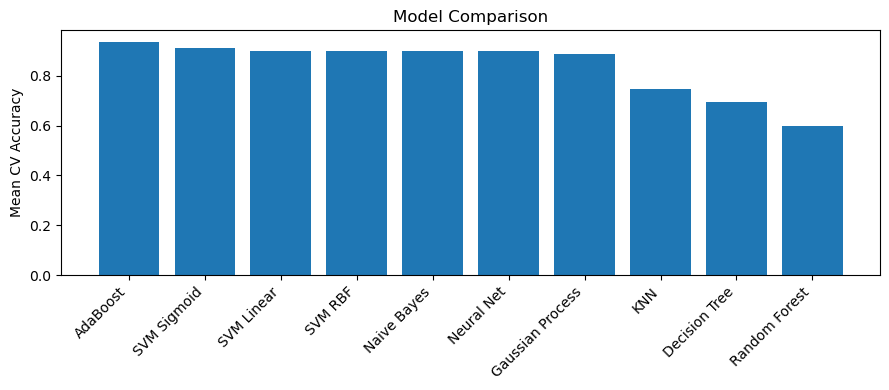

In [16]:
#%matplotlib inline
plt.figure(figsize=(9, 4))
plt.bar(results_df['Model'], results_df['Mean Accuracy'])
plt.xticks(rotation=45, ha='right')
plt.ylabel('Mean CV Accuracy')
plt.title('Model Comparison')
plt.tight_layout()
plt.show()

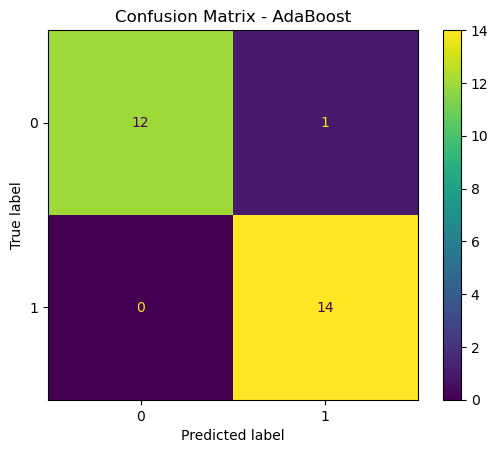

In [17]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

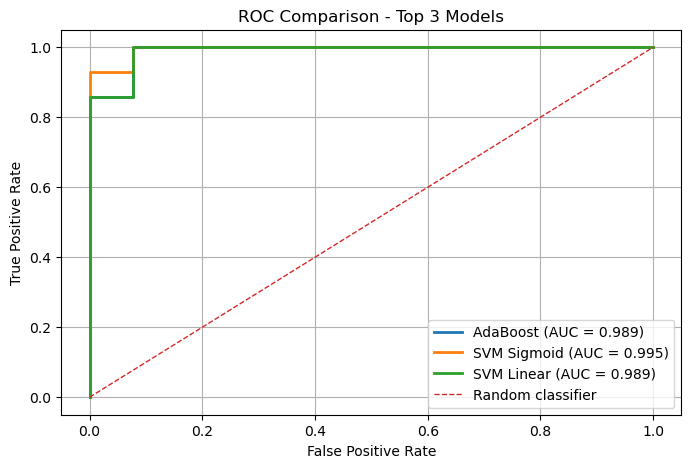

In [18]:
### ROC Comparison of the Top 3 Models

# Select the top 3 models from the cross-validation ranking
top_3_model_names = results_df.head(3)['Model'].tolist()

plt.figure(figsize=(8, 5))

for model_name in top_3_model_names:
    model = models[model_name]
    model.fit(X_train, y_train)

    # Get scores required for ROC computation
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(X_test)
    else:
        print(f"Skipping {model_name}: ROC not supported.")
        continue

    # Compute ROC and AUC
    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = roc_auc_score(y_test, y_score)

    # Plot each ROC curve
    plt.plot(fpr, tpr, linewidth=2, label=f"{model_name} (AUC = {roc_auc:.3f})")

# Random baseline
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1, label="Random classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Comparison - Top 3 Models")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

The top-performing classifiers all show strong discriminative ability. The best model achieved the highest AUC, indicating robust separation between promoter and non-promoter DNA sequences.

## Interpretation of the results
The results suggest that promoter and non-promoter sequences contain recognizable patterns that can be captured by machine learning models after suitable encoding. However, performance should be interpreted with caution because the dataset is limited in size and simplified compared with real-world genomic data.

## 11. Conclusion
This project shows that DNA sequences can be converted into numerical representations and classified using standard machine learning methods. By comparing several algorithms, the notebook provides a clear example of sequence-based classification in a bioinformatics context.

More broadly, this workflow illustrates how biological sequence data can be prepared for computational analysis and used to address problems related to gene regulation.

## Limitations
This project uses a relatively small and already structured dataset, so it does not represent a full genomics or Next-Generation Sequencing (NGS) analysis pipeline. In addition, one-hot encoding captures positional nucleotide identity but does not explicitly model more complex sequence motifs or long-range dependencies.

## Future Work
Possible extensions of this work include hyperparameter tuning, feature extraction using k-mers, testing deep learning models such as CNNs, and evaluating the approach on larger real-world genomic datasets.